In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
# Set plot style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [35]:
# Data Loading, Cleaning, and Preprocessing
df = pd.read_csv('regression_training_dataset.csv') 
print(f'Dataset shape: {df.shape}')
print(df.isnull().sum())

Dataset shape: (200, 5)
StudyHoursPerWeek       0
AttendancePercent       0
AssignmentsCompleted    0
ExperienceYears         0
PerformanceScore        0
dtype: int64


In [36]:
X = df.drop(columns="PerformanceScore")
y = df["PerformanceScore"]

In [37]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Convert scaled arrays back to DataFrames for VIF calculation later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_train_scaled_df

,StudyHoursPerWeek,AttendancePercent,AssignmentsCompleted,ExperienceYears
0,1.203760,0.927674,-1.194514,0.927239
1,-0.543986,0.589377,0.460224,0.321695
2,-1.243084,-1.440405,-1.690936,-1.192164
3,1.203760,-1.778702,1.287593,-1.494936
4,-0.893535,0.166506,0.460224,-1.494936
...,...,...,...,...
155,-0.893535,1.265971,0.625698,-1.192164
156,0.155112,-0.256366,-0.698093,-0.586621
157,-0.194437,0.927674,0.791172,0.018923
158,0.155112,0.504803,-0.863566,0.927239


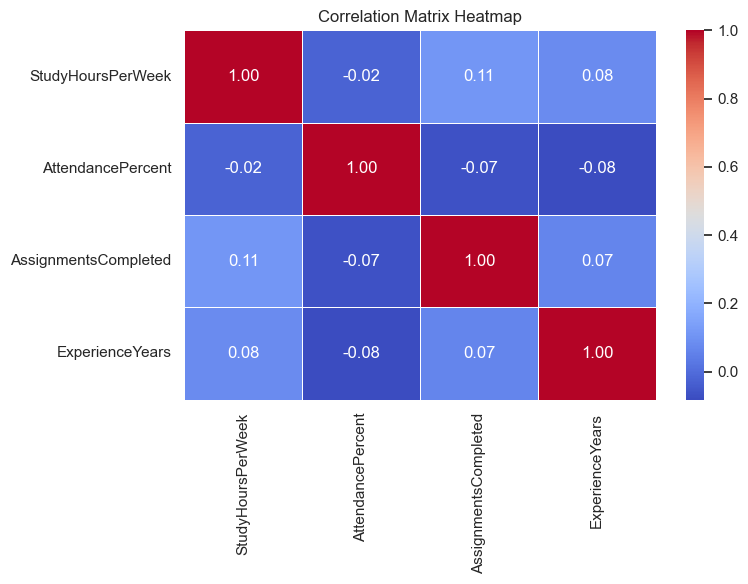

In [40]:
# Correaltion Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X_train_scaled_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.png')
plt.show()
plt.close()

C:\Users\MSI\AppData\Local\Temp\ipykernel_17436\1702319148.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


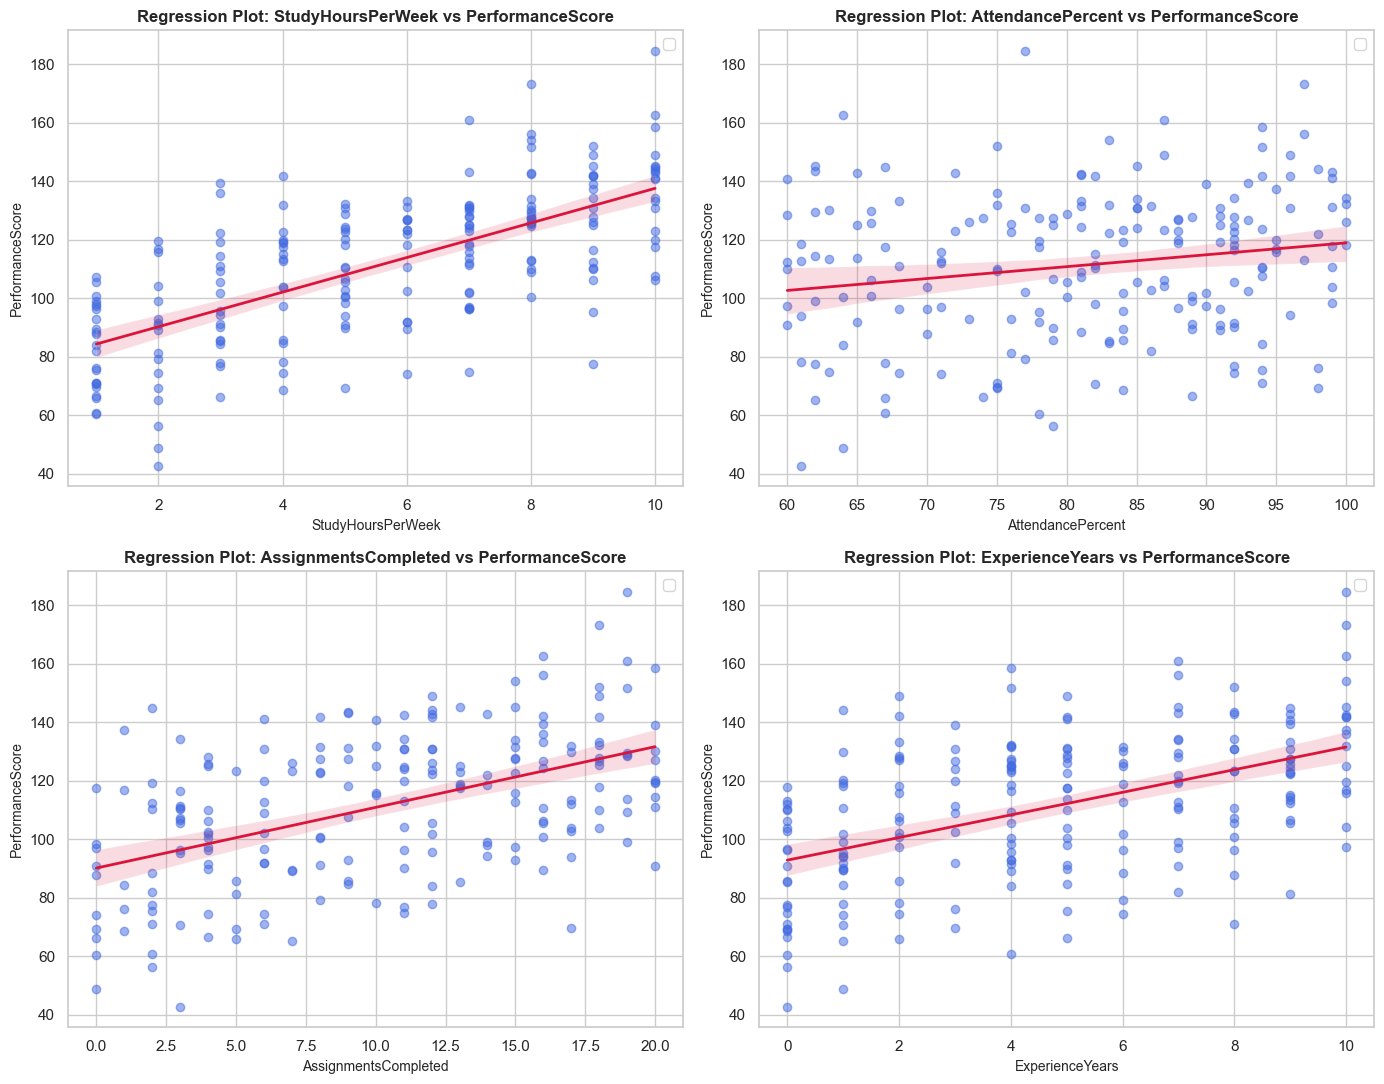

EDA plots saved as 'eda_features_vs_target_best_fit.png'.


In [41]:
fig,axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.regplot(
        x = df[col],
        y = df['PerformanceScore'],
        ax = axes[i],
        scatter_kws={'alpha':0.5, 'color':'royalblue'},
        line_kws={'color':'crimson', 'linewidth':2}
    )
    axes[i].set_title(f'Regression Plot: {col} vs PerformanceScore', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('PerformanceScore', fontsize=10)
    axes[i].legend()
    
plt.tight_layout()
plt.savefig('eda_features_vs_target_best_fit.png')
plt.show()
plt.close()
print("EDA plots saved as 'eda_features_vs_target_best_fit.png'.")

In [ ]:
# Helper Evaluation Function
models_report = {}
trained_models = {}

def evaluate_model(model, name, X_tr, X_te, y_tr, y_te):
    # predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Calculate metrics
    metrics = {
        'Train RMSE': np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'Train MAE': mean_absolute_error(y_tr, y_pred_train),
        'Test MAE': mean_absolute_error(y_te, y_pred_test),
        'Train R2': r2_score(y_tr, y_pred_train),
        'Test R2': r2_score(y_te, y_pred_test)
    }
    
    models_report[name] = metrics
    trained_models[name] = model
    
    print(f"\n [{name} Performance Metrics]")
    print(f"Train R²: {metrics['Train R2']:.4f}, Test R²: {metrics['Test R2']:.4f}")
    print(f"Train RMSE: {metrics['Train RMSE']:.4f}, Test RMSE: {metrics['Test RMSE']:.4f}")
    return metrics

In [44]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
evaluate_model(lr_model, "Linear Regression", X_train_scaled, X_test_scaled, y_train, y_test)


 [Linear Regression Performance Metrics]
Train R²: 0.8877, Test R²: 0.8985
Train RMSE: 8.2721, Test RMSE: 8.5239


{'Train RMSE': np.float64(8.272081342859593),
 'Test RMSE': np.float64(8.523864321618145),
 'Train MAE': 6.4390001682484925,
 'Test MAE': 6.8035885180645534,
 'Train R2': 0.8877433196170723,
 'Test R2': 0.8985064262772665}

In [45]:
# check multicollinearity using VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled_df.values, i) for i in range(len(X.columns))]
print("\nVariance Inflation Factor (VIF) for each feature:")
print(vif_data)


Variance Inflation Factor (VIF) for each feature:
                feature       VIF
0     StudyHoursPerWeek  1.018685
1     AttendancePercent  1.010818
2  AssignmentsCompleted  1.019966
3       ExperienceYears  1.016077
